## 1. Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load Data


In [ ]:
df = pd.read_csv(r"C:\Users\Naz\Desktop\Naz\jobs\inv\Code\fabenode-data-report\data\raw\user_48_feb02_14_full_hrv.csv")

## 3. Datetime Preparation

In [ ]:
df["start_time"] = pd.to_datetime(df["start_time"])
df["finish_time"] = pd.to_datetime(df["finish_time"])

## 4. Movement Columns Overview


In [ ]:
movement_cols=["movement","movement_mean", "movement_std"]

In [ ]:
df[movement_cols].head(10)

,movement,movement_mean,movement_std
0,1.0,0.119,0.106
1,1.0,0.139,0.108
2,1.0,0.153,0.114
3,1.0,0.148,0.104
4,1.0,0.147,0.104
5,1.0,0.142,0.103
6,1.0,0.149,0.100
7,2.0,0.155,0.118
8,1.0,0.148,0.117
9,1.0,0.143,0.111


In [ ]:
df[movement_cols].describe()

,movement,movement_mean,movement_std
count,3038.000000,3038.000000,3038.000000
mean,1.225806,0.142278,0.124881
std,0.526886,0.078197,0.069735
min,1.000000,0.001000,0.000000
25%,1.000000,0.100000,0.079000
50%,1.000000,0.125000,0.104000
75%,1.000000,0.171750,0.158000
max,5.000000,0.655000,0.494000


In [ ]:
df["movement"].value_counts(dropna=False).sort_index()

movement
1.0    2476
2.0     464
3.0      78
4.0      14
5.0       6
NaN      99
Name: count, dtype: int64

Movement is highly concentrated at the lowest level, indicating that most recorded segments occur during minimal motion.

## 5. Distribution of Movement Variables

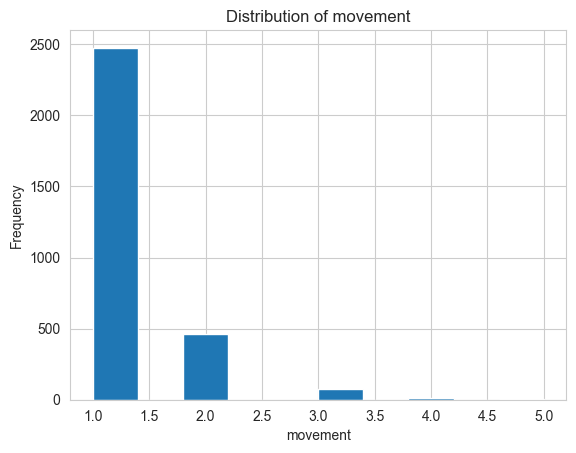

In [ ]:
df["movement"].hist(bins=10)
plt.title("Distribution of movement")
plt.xlabel("movement")
plt.ylabel("Frequency")
plt.show()

The movement variable is highly imbalanced, with the majority of observations in the lowest category and progressively fewer observations at higher movement levels.

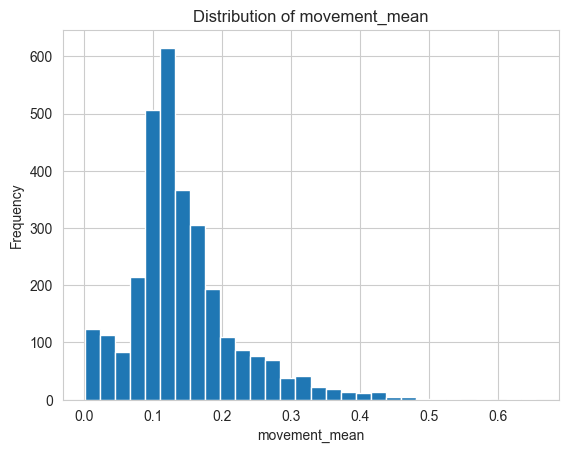

In [ ]:
df["movement_mean"].hist(bins=30)
plt.title("Distribution of movement_mean")
plt.xlabel("movement_mean")
plt.ylabel("Frequency")
plt.show()

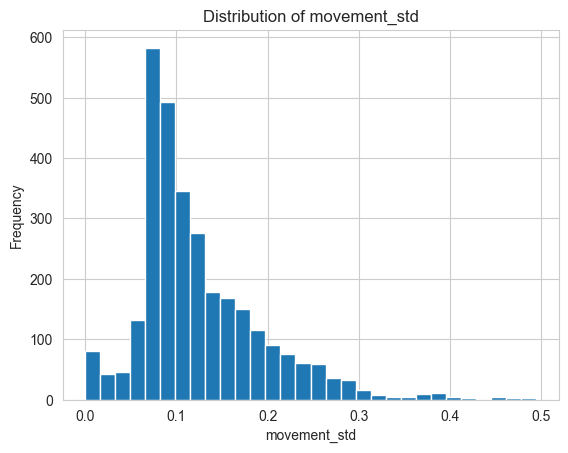

In [ ]:
df["movement_std"].hist(bins=30)
plt.title("Distribution of movement_std")
plt.xlabel("movement_std")
plt.ylabel("Frequency")
plt.show()

Both movement_mean and movement_std are right-skewed, indicating that most windows have low movement, with occasional periods of higher activity.

## 6. Movement vs Signal Quality

In [ ]:
df.groupby("is_ekg_quality")[["movement_mean", "movement_std"]].mean()

,movement_mean,movement_std
is_ekg_quality,,
False,0.130408,0.116623
True,0.148850,0.131455


Movement does not appear to degrade signal quality directly, and higher-quality segments may even exhibit slightly higher movement levels. This suggests that factors other than movement (e.g., sensor contact or signal characteristics) play a more dominant role in determining signal quality

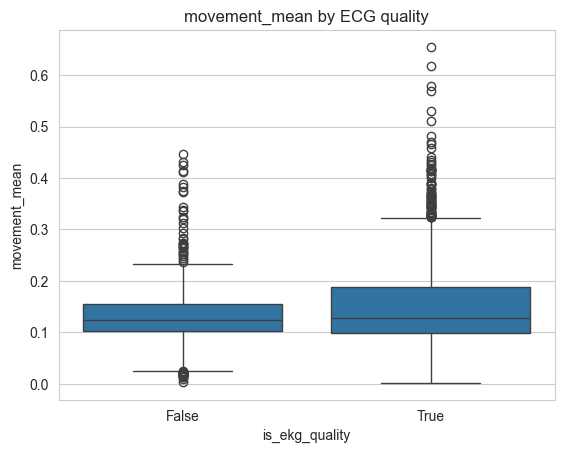

In [ ]:
sns.boxplot(x="is_ekg_quality", y="movement_mean", data=df)
plt.title("movement_mean by ECG quality")
plt.xlabel("is_ekg_quality")
plt.ylabel("movement_mean")
plt.show()

Movement distributions for good and bad quality segments are largely overlapping, with similar central values. While good-quality segments show slightly higher variability, movement does not strongly differentiate signal quality.

You are testing:

Can movement explain signal quality?

Your result:

👉 No strong evidence

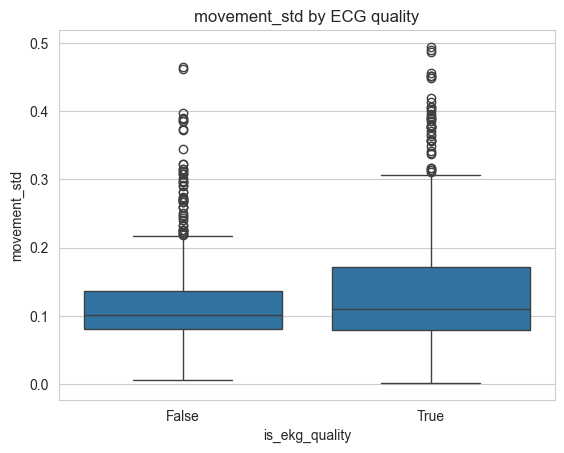

In [ ]:
sns.boxplot(x="is_ekg_quality", y="movement_std", data=df)
plt.title("movement_std by ECG quality")
plt.xlabel("is_ekg_quality")
plt.ylabel("movement_std")
plt.show()

## 7. Key Findings

### Movement Distribution
- The `movement` variable is a discrete ordinal feature ranging from 1 to 5, representing different levels of activity intensity.
- The distribution is highly imbalanced, with the majority of observations concentrated in the lowest category (1), indicating that the subject is mostly inactive.
- Higher movement levels (3–5) are rare and represent only a small fraction of the data.

### Movement Statistics
- `movement_mean` and `movement_std` are continuous variables summarizing movement intensity and variability within each time window.
- Both variables exhibit right-skewed distributions, meaning most windows have low movement, with occasional higher values.
- This suggests that while high movement is uncommon, it can occur in bursts.

### Relationship with Signal Quality
- The median values of both `movement_mean` and `movement_std` are similar across good and poor ECG quality groups.
- Boxplot analysis shows substantial overlap between the distributions of the two groups.
- Although the high-quality group exhibits slightly higher variability (larger spread), this difference is not strong enough to clearly separate the groups.

### Interpretation of Movement Impact
- Movement does not appear to be a dominant factor affecting ECG signal quality in this dataset.
- Both low and moderate movement levels are present in good and poor quality segments.
- This suggests that other factors, such as sensor contact or signal characteristics, may play a more significant role in determining signal quality.

### Overall Insight
- Movement, both in terms of intensity (`movement_mean`) and variability (`movement_std`), has a weak relationship with ECG signal quality.
- Therefore, movement alone is not sufficient to explain signal degradation and should not be used as the primary filtering criterion for downstream analysis.